# Optical Properties with CASTEP

Many of the properties we are interested in can be calculated with a "optics" calculation. This involves calculating a well-sampled general electronic structure and using it to simulate optical absorption.

`solphin` provides methods to write input files and read output files to calculate this using CASTEP.

Pre-requisites:
* Geometry Optimisation/Structural Relaxation

## Calculation

1) Import the necessary libraries.

In [2]:
import solphin.castep_inputs as castep_inputs
import solphin.vasp_inputs as vasp_inputs

2) Define our computational regime. This should be the same regime used to relax the structure.

In [3]:
functional = "HSE06"      # The DFT functional
cut_off_energy = 450      # Plane-wave cut-off in eV
kpoint_mp_spacing = 0.03  # Maximum k-point spacing in Angstrom^-1, no 2*pi factor

3) Load the optimised atomic structure from a previous relaxation. Here we read from the bundled test data. 

In [4]:
structure = vasp_inputs.read_structure_pmg("../tests/data/Cu2GeS3/Relax/CONTCAR")

4) Write the input files. Here we write to `workdir` which is untracked, and can be used to try out these tutorials.

In [5]:
dos_out = "workdir/DOS"
optics_out = "workdir/OPT"

castep_inputs.write_castep_calculation(
    structure=structure,
    recipe=functional,
    out_dir=dos_out,
    patches=["dos"],
    kpoint_mp_spacing=kpoint_mp_spacing,
    user_param_settings={"cut_off_energy": cut_off_energy},
)

optics_cell = castep_inputs.write_castep_calculation(
    structure=structure,
    recipe=functional,
    out_dir=optics_out,
    patches=["optics"],
    kpoint_mp_spacing=kpoint_mp_spacing,
    user_param_settings={"cut_off_energy": cut_off_energy},
)

5. Run the CASTEP calculations.

6. Post-process the results with OptaDOS:

    CASTEP stops at the optical matrix elements; the dielectric function itself comes from OptaDOS, a Fortran post-processing tool distributed alongside CASTEP. With the optics run finished, put a `<seed>.odi` beside its output and run `optados <seed>`. A minimal one:

    ```
    task         : optics
    optics_geom  : polycrystalline
    broadening   : adaptive
    jdos_spacing : 0.01
    ```

    That writes `<seed>_epsilon.dat`, which is the file `solphin` reads.

    * **`optics_geom`.** Both the default `polycrystalline` and `tensor` are understood; a polycrystalline spectrum is treated as an isotropic tensor.
    * **Broadening** is an OptaDOS setting, not a CASTEP one.

## Analysis

We can also use `solphin` to plot a Density of States and simulatied optical absorption curve. We are going to use the sample data packaged with the tests.

1) Import the necessary libraries

In [6]:
import solphin.dos as dos
import solphin.optics as optics
%matplotlib inline

2) Plot the electronic Density of States (DOS)

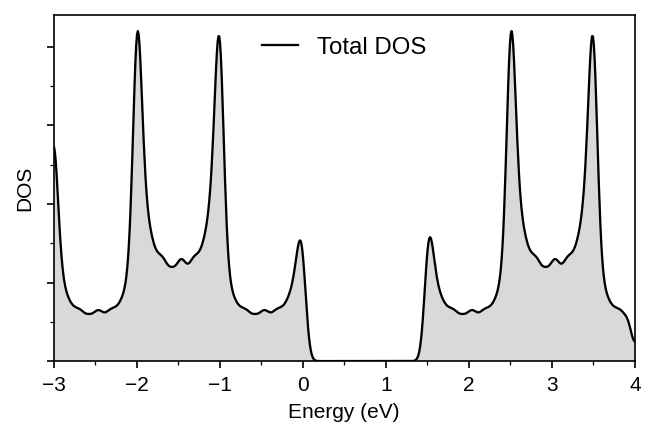

In [7]:
dos.plot_dos(filename="../tests/data/castep_toy/BAND/toy.bands", xmin=-3, xmax=4, gaussian=0.05, code="castep")

3. Plot the simulated absorption spectrum

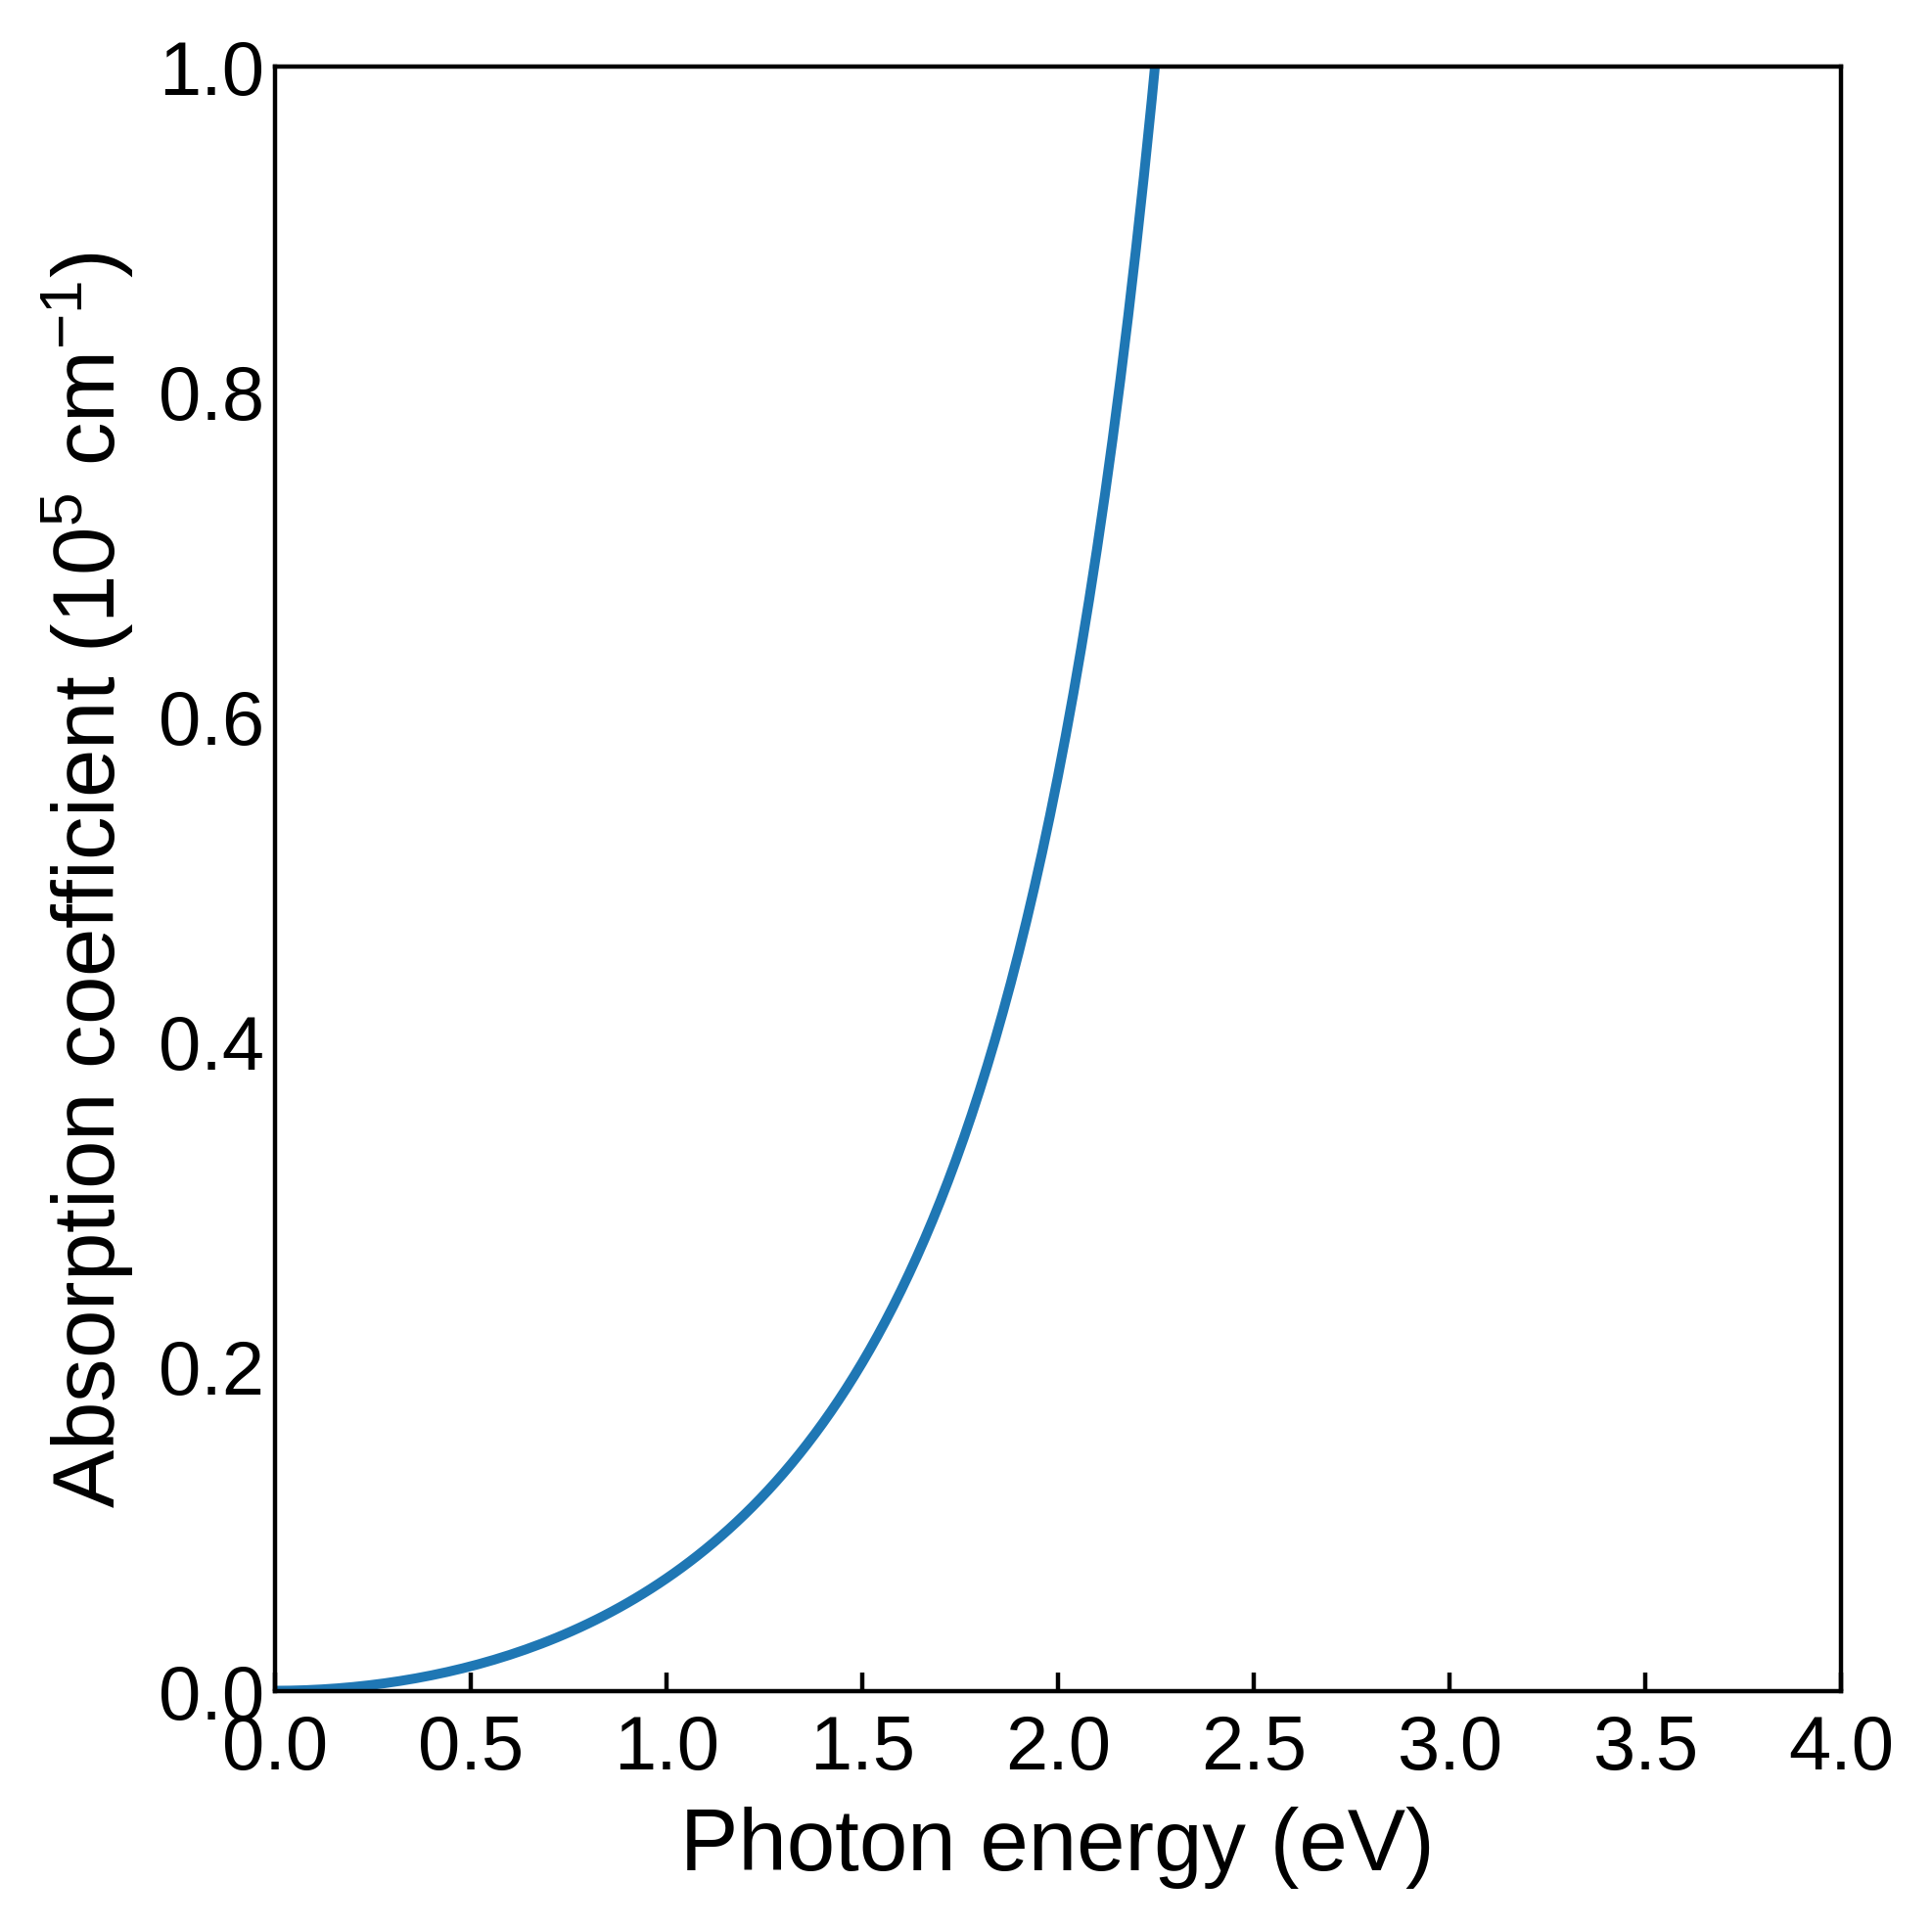

In [8]:
optics.plot_absorption(optics_directory="../tests/data/castep_toy/OPT", code="castep")